### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Mistral's open source LLM [Ministral 3B-Instruct](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512) for prompting

 - All experiments will be performed on the [Go Emotions Dataset](https://huggingface.co/datasets/google-research-datasets/go_emotions).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("go_emotions", "simplified", split="train")
test_data = load_dataset("go_emotions", "simplified", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 43410 examples
Test set size: 5427 examples


In [3]:
# filter to keep only single-label examples:
def is_single_label(example):
    return len(example["labels"]) == 1

train_data = train_data.filter(is_single_label)
test_data = test_data.filter(is_single_label)

# flatten the label from list to scalar:
def flatten_label(example):
    example["label"] = example["labels"][0]
    return example

train_data = train_data.map(flatten_label)
test_data = test_data.map(flatten_label)

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 36308 examples
Test set size: 4590 examples


In [4]:
# get the label names:
label_names = train_data.features['labels'].feature.names

# create a mapping from index to label:
index2label = {i: name for i, name in enumerate(label_names)}

In [5]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

train_df.sample()

,text,labels,id,label
26860,You must have a different definition of exciti...,[4],eenq5a1,4


In [6]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

# create the development set:
train_df, dev_df = train_test_split(
    train_df, stratify=train_df["label"], test_size=0.2, shuffle=True, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Dev subset size: {len(dev_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 1600 examples
Dev subset size: 400 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [7]:
# map numeric labels to string labels:
train_df['label'] = train_df['label'].map(index2label)
dev_df['label'] = dev_df['label'].map(index2label)
test_df['label'] = test_df['label'].map(index2label)

In [8]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label'].to_numpy()

X_dev = dev_df['text'].to_numpy()
y_dev = dev_df['label'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  28


### Dense Embeddings for Similarity (Contriever)

We import the Contriever model from `transformers` and use it to create dense vector embeddings for our texts. Unlike TF-IDF, Contriever produces dense representations directly, so no sparse-to-dense conversion is needed.

We define a utility function (`phi`) that encodes a list of texts into embeddings using the model. Since Contriever operates at the token level, we apply mean pooling over token embeddings to obtain a single vector representation per text.

In [9]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# load Contriever model
tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
model = AutoModel.from_pretrained("facebook/contriever")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# mean pooling function
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1)

# define embedding function (batched to avoid OOM):
def phi(texts, batch_size=32):
    if hasattr(texts, "tolist"):
        texts = texts.tolist()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=512
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)
# test embedding shape
phi(X_train[:2].tolist()).shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 768)

In [10]:
import gc

# pre-compute all embeddings before loading LLM:
print("Pre-computing train embeddings...")
X_train_emb = phi(X_train)
print("Pre-computing test embeddings...")
X_test_emb = phi(X_test)
print(f"X_train_emb: {X_train_emb.shape}, X_test_emb: {X_test_emb.shape}")

# free Contriever from GPU to make room for LLM:
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Contriever freed from GPU memory.")

Pre-computing train embeddings...


Pre-computing test embeddings...


X_train_emb: (1600, 768), X_test_emb: (1000, 768)


Contriever freed from GPU memory.


Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [11]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'admiration': 0,
 'amusement': 1,
 'anger': 2,
 'annoyance': 3,
 'approval': 4,
 'caring': 5,
 'confusion': 6,
 'curiosity': 7,
 'desire': 8,
 'disappointment': 9,
 'disapproval': 10,
 'disgust': 11,
 'embarrassment': 12,
 'excitement': 13,
 'fear': 14,
 'gratitude': 15,
 'grief': 16,
 'joy': 17,
 'love': 18,
 'nervousness': 19,
 'neutral': 20,
 'optimism': 21,
 'pride': 22,
 'realization': 23,
 'relief': 24,
 'remorse': 25,
 'sadness': 26,
 'surprise': 27}

In [12]:
from sklearn.metrics import pairwise_distances

def get_fixed_k_examples(test_idx, k=2):
    """
    Return exactly k training examples with highest cosine similarity to X_test[test_idx],
    selected globally across all classes.
    Returns list of (text, label, similarity) tuples sorted by descending similarity.
    """
    test_emb = X_test_emb[test_idx:test_idx+1]
    similarity = (1. - pairwise_distances(test_emb, X_train_emb, metric="cosine"))[0]
    top_k_idx = np.argsort(similarity)[::-1][:k]
    return [(X_train[i], y_train[i], similarity[i]) for i in top_k_idx]

In [13]:
# verify: show the 4 globally most similar training examples to the first test sample:
n = 4
examples = get_fixed_k_examples(0, k=n)
print(f"Query: {X_test[0]!r}\n")
for i, (text, label, sim) in enumerate(examples):
    print(f"{i+1}. [{label}] (sim={sim:.3f}) {text!r}")

Query: 'In what ways has [NAME] out-coached [NAME]? I see this all the time and yet never any examples.'

1. [neutral] (sim=0.601) 'is [NAME] playing?'
2. [neutral] (sim=0.591) 'That was [NAME] not [NAME]'
3. [disapproval] (sim=0.591) '[NAME], stop being [NAME].'
4. [neutral] (sim=0.590) '[NAME] and [NAME] are mad at [NAME].'


### Instantiate Ministral

In order to be able to use huggingface's Mistral models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512)).

In [14]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 3B parameter version of Ministral.

In [15]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="mistralai/Ministral-3-3B-Instruct-2512",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto"
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id or llm.tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


FP8 quantized models is only supported on GPUs with compute capability >= 8.9 (e.g 4090/H100), actual = `8.6`. We will default to dequantizing the model to bf16. Feel free to use a different quantization method like bitsandbytes or torchao


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

The model 'Mistral3ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM', 'FalconH1ForC

### Results Handling Helper

In [16]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [17]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Few-shot learning with Most Similar Examples (Dense Embeddings / Contriever)

Generate a prompt for classification using a given text and $n$ labeled examples.

In [18]:
def get_prompt(text, shots):
    replace_qm = lambda s: s.replace('"', "'")
    prompt = 'We classify user questions into topic categories based on their text. Here are some labelled examples:\n'
    for x,y in shots: prompt += f'\n"{replace_qm(x)}" => {y}'
    return {"role": "user", "content": f'{prompt}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

shots_examples = get_fixed_k_examples(0, k=n)
shots = [(x, y) for x, y, _ in shots_examples]
prompt = get_prompt(X_test[0], shots)["content"]
print(prompt)

We classify user questions into topic categories based on their text. Here are some labelled examples:

"is [NAME] playing?" => neutral
"That was [NAME] not [NAME]" => neutral
"[NAME], stop being [NAME]." => disapproval
"[NAME] and [NAME] are mad at [NAME]." => neutral

Please predict the correct class for the following sample. Only provide the class label.

"In what ways has [NAME] out-coached [NAME]? I see this all the time and yet never any examples." => 


In [19]:
from tqdm import tqdm
import numpy as np

predictions = []
prompt_lengths = []
input_lengths = []
shots_lengths = []
num_shots = []

n = 4
for i, x in tqdm(enumerate(X_test), total=len(X_test), desc='Assessing texts'):
    shots_examples = get_fixed_k_examples(i, k=n)
    shots = [(x_s, y_s) for x_s, y_s, _ in shots_examples]
    prompt = get_prompt(x, shots)
    prompt_len = len(llm.tokenizer(prompt["content"])["input_ids"])
    input_len = len(llm.tokenizer(x)["input_ids"])
    shots_text = "\n".join([x_s for x_s, _ in shots])
    shots_len = len(llm.tokenizer(shots_text)["input_ids"])
    prompt_lengths.append(prompt_len)
    input_lengths.append(input_len)
    shots_lengths.append(shots_len)
    num_shots.append(len(shots))
    predictions.append(llm([prompt],
        bos_token_id=bos_token_id,
        eos_token_id=eos_token_id,
        pad_token_id=pad_token_id,
        max_new_tokens=5,
        do_sample=False,
        temperature=None,
        top_p=None,
    )[0]["generated_text"][-1]["content"].strip())

print(f"Average prompt length:        {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length:         {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average num shots:            {np.mean(num_shots):.1f}")

Assessing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'bos_token_id', 'eos_token_id', 'do_sample', 'top_p', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts:   0%|          | 1/1000 [00:00<10:25,  1.60it/s]

Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Assessing texts: 100%|█████████▉| 999/1000 [04:15<00:00,  5.39it/s]

Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|██████████| 1000/1000 [04:15<00:00,  5.56it/s]

Assessing texts: 100%|██████████| 1000/1000 [04:15<00:00,  3.91it/s]

Average prompt length:        128.2 tokens
Average input length:         16.6 tokens
Average shots section length: 60.0 tokens
Average num shots:            4.0


In [20]:
predictions[:10]

['disapproval',
 'optimism',
 'gratitude',
 'disapproval',
 'anger',
 'admiration',
 'anger',
 'sadness',
 'sorrow',
 'relief']

Classification Report:
                 precision    recall  f1-score   support

   disapproval       0.13      0.19      0.15        42
     amusement       0.37      0.39      0.38        41
     confusion       0.17      0.10      0.12        21
        caring       0.27      0.16      0.20        19
          love       0.45      0.37      0.41        35
      surprise       0.17      0.05      0.08        19
       remorse       0.38      0.30      0.33        10
       disgust       0.24      0.29      0.26        17
          fear       0.25      0.21      0.23        14
           joy       0.18      0.15      0.16        20
      optimism       0.38      0.22      0.28        23
disappointment       0.06      0.05      0.06        19
   realization       0.06      0.05      0.05        19
    excitement       0.10      0.17      0.12        12
        relief       0.00      0.00      0.00         2
        desire       0.25      0.17      0.20        12
     annoyance       0.

Text(0.5, 1.0, 'Confusion Matrix')

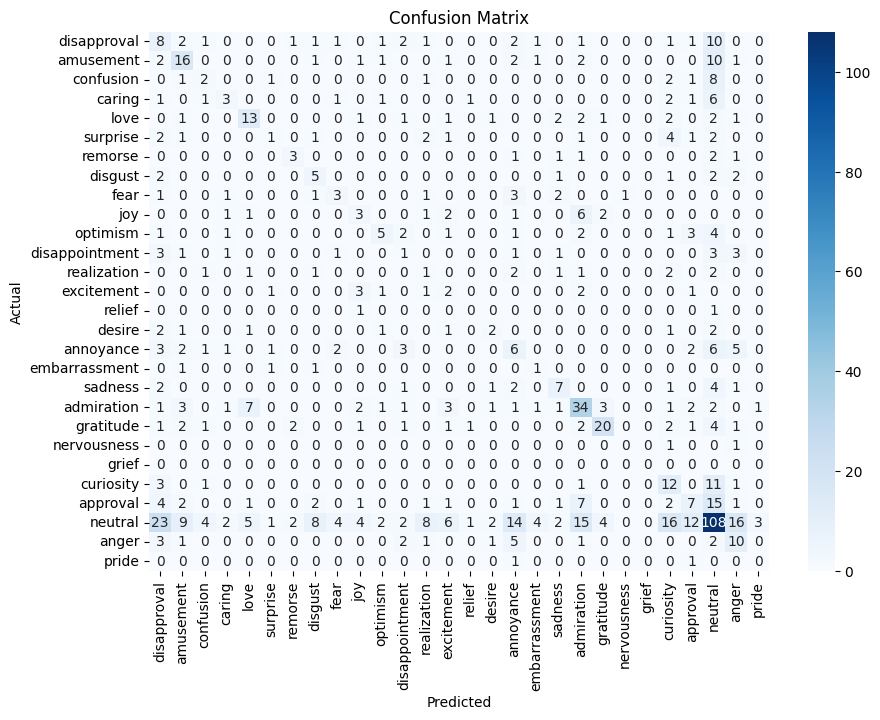

In [21]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [22]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-ministral-3b-fewshot-contriever-2.0k-samples-4-shots-fixed.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-ministral-3b-fewshot-contriever-2.0k-samples-4-shots-fixed.json'


In [23]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-ministral-3b-fewshot-contriever-2.0k-samples-4-shots-fixed.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-ministral-3b-fewshot-contriever-2.0k-samples-4-shots-fixed.json'
